In [1]:
import sys
sys.path.insert(0, '/home/ubuntu/prem')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import geopandas as gpd
from shapely import wkt
from shapely.geometry import Point
from scipy.ndimage import gaussian_filter
import warnings
import gc  # For memory management

warnings.filterwarnings('ignore')

plt.style.use('default')
sns.set_palette('husl')

## 1. Load All Near-Miss Data (14 Days)

In [2]:
# NOTE: This cell has been replaced by cells in section 1.5 below
# The new approach extracts position information from parquet files
# Run the cells in section 1.5 instead of this cell

# # OLD CODE (kept for reference):
# # Load data from all 14 days
# results_dir = Path("/home/ubuntu/prem/results/brussels/mdrac")
#
# all_conflicts = []
# daily_stats = []
#
# for day in range(1, 15):
#     day_str = f"{day:02d}"
#     csv_path = results_dir / day_str / f"mdrac_{day_str}.csv"
#     
#     if csv_path.exists():
#         df_day = pd.read_csv(csv_path)
#         df_day['day'] = day
#         all_conflicts.append(df_day)
#         
#         daily_stats.append({
#             'Day': day,
#             'Date': f"2025-06-{day:02d}",
#             'Conflicts': len(df_day)
#         })
#         print(f"Day {day_str}: {len(df_day):,} conflicts")
#     else:
#         daily_stats.append({
#             'Day': day,
#             'Date': f"2025-06-{day:02d}",
#             'Conflicts': 0
#         })
#         print(f"Day {day_str}: No data found")
#
# # Combine all data
# if all_conflicts:
#     df_all = pd.concat(all_conflicts, ignore_index=True)
#     print(f"\n✓ Total conflicts across 14 days: {len(df_all):,}")
# else:
#     df_all = pd.DataFrame()
#     print("\n✗ No conflict data found")
#
# # Create stats table
# stats_df = pd.DataFrame(daily_stats)

print("⚠ Skip this cell - Use section 1.5 instead for position extraction")

⚠ Skip this cell - Use section 1.5 instead for position extraction


## 1.5. Extract Position Information from Parquet Files

Since MDRAC detections only contain `id1`, `id2`, and `timestamp`, we need to extract position data from the original parquet files by matching on these fields. We'll process one day at a time to avoid memory issues.

In [3]:
def extract_positions_for_day(day, detections_df, data_dir="/home/ubuntu/data/uploads/objects/clean"):
    """
    Extract position information for detections on a specific day.
    Uses vectorized merge operations for fast matching (1000x faster than iterrows).
    
    Args:
        day: Day number (1-14)
        detections_df: DataFrame with detection data (must have timestamp, id1, id2)
        data_dir: Path to parquet data directory
    
    Returns:
        DataFrame with added position columns (pos_x1, pos_y1, pos_x2, pos_y2)
    """
    from datetime import datetime
    import glob
    
    # Date string for this day
    date_str = f"2025-06-{day:02d}"
    
    print(f"\n{'='*60}")
    print(f"Processing Day {day:02d} ({date_str})")
    print(f"{'='*60}")
    
    # Filter detections for this day
    detections_df['timestamp_dt'] = pd.to_datetime(detections_df['timestamp'])
    detections_df['date'] = detections_df['timestamp_dt'].dt.date
    day_detections = detections_df[detections_df['date'] == pd.to_datetime(date_str).date()].copy()
    
    if len(day_detections) == 0:
        print(f"⚠ No detections found for day {day}")
        return pd.DataFrame()
    
    print(f"Found {len(day_detections)} detections to enrich")
    
    # Get all hourly folders for this day
    hourly_folders = sorted(glob.glob(f"{data_dir}/{date_str}-*"))
    print(f"Found {len(hourly_folders)} hourly folders")
    
    # Collect all parquet data for this day (load hour by hour)
    all_parquet_data = []
    
    for hour_folder in hourly_folders:
        parquet_files = sorted(glob.glob(f"{hour_folder}/*.parquet"))
        
        for parquet_file in parquet_files:
            # Load parquet file with only needed columns
            df_parquet = pd.read_parquet(parquet_file, columns=['timestamp', 'id', 'pos_x', 'pos_y'])
            df_parquet['timestamp'] = pd.to_datetime(df_parquet['timestamp'])
            all_parquet_data.append(df_parquet)
            
            # Clear memory
            del df_parquet
            gc.collect()
        
        print(f"  Loaded hour {hour_folder.split('/')[-1]}", end='\r')
    
    # Combine all parquet data for this day
    print(f"\n  Combining parquet data...")
    df_positions = pd.concat(all_parquet_data, ignore_index=True)
    del all_parquet_data
    gc.collect()
    
    print(f"  Total position records: {len(df_positions):,}")
    
    # Merge id1 positions (vectorized operation - FAST!)
    print(f"  Matching id1 positions...")
    day_detections = day_detections.merge(
        df_positions[['timestamp', 'id', 'pos_x', 'pos_y']],
        left_on=['timestamp_dt', 'id1'],
        right_on=['timestamp', 'id'],
        how='left',
        suffixes=('', '_tmp')
    )
    day_detections.rename(columns={'pos_x': 'pos_x1', 'pos_y': 'pos_y1'}, inplace=True)
    day_detections.drop(['id', 'timestamp_tmp'], axis=1, inplace=True, errors='ignore')
    
    # Merge id2 positions (vectorized operation - FAST!)
    print(f"  Matching id2 positions...")
    day_detections = day_detections.merge(
        df_positions[['timestamp', 'id', 'pos_x', 'pos_y']],
        left_on=['timestamp_dt', 'id2'],
        right_on=['timestamp', 'id'],
        how='left',
        suffixes=('', '_tmp')
    )
    day_detections.rename(columns={'pos_x': 'pos_x2', 'pos_y': 'pos_y2'}, inplace=True)
    day_detections.drop(['id', 'timestamp_tmp'], axis=1, inplace=True, errors='ignore')
    
    # Clear parquet data from memory
    del df_positions
    gc.collect()
    
    # Count matches
    matched_count = day_detections[['pos_x1', 'pos_y1', 'pos_x2', 'pos_y2']].notna().all(axis=1).sum()
    print(f"✓ Matched {matched_count}/{len(day_detections)} detections ({matched_count/len(day_detections)*100:.1f}%)")
    
    # Drop temporary columns
    day_detections = day_detections.drop(['timestamp_dt', 'date'], axis=1, errors='ignore')
    
    return day_detections

In [4]:
# Process all 14 days one at a time
results_base = Path("/home/ubuntu/prem/results/brussels")
lanes_dir = results_base / "lanes"
crosswalks_dir = results_base / "crosswalks"
data_dir = "/home/ubuntu/data/uploads/objects/clean"

all_enriched_detections = []
daily_stats = []

print("Starting position extraction for 14 days...")
print("This will process one day at a time to manage memory efficiently.\n")

for day in range(1, 15):
    date_str = f"2025-06-{day:02d}"
    
    # Load from BOTH lanes and crosswalks directories
    lanes_csv = lanes_dir / date_str / f"mdrac_{date_str}.csv"
    crosswalks_csv = crosswalks_dir / date_str / f"mdrac_{date_str}.csv"
    
    dfs_to_load = []
    
    if lanes_csv.exists():
        dfs_to_load.append(('lanes', pd.read_csv(lanes_csv)))
    
    if crosswalks_csv.exists():
        dfs_to_load.append(('crosswalks', pd.read_csv(crosswalks_csv)))
    
    if not dfs_to_load:
        print(f"⚠ Day {day} ({date_str}): No MDRAC files found")
        daily_stats.append({'Day': day, 'Date': date_str, 'Conflicts': 0})
        continue
    
    # Combine detections from both sources
    df_day = pd.concat([df for _, df in dfs_to_load], ignore_index=True)
    original_count = len(df_day)
    
    print(f"Day {day} ({date_str}): Loaded {len([name for name, _ in dfs_to_load])} source(s) - {original_count} detections")
    
    # Extract positions
    df_enriched = extract_positions_for_day(day, df_day, data_dir)
    
    if len(df_enriched) > 0:
        df_enriched['day'] = day
        all_enriched_detections.append(df_enriched)
        
        # Count successfully enriched detections
        enriched_count = df_enriched[['pos_x1', 'pos_y1', 'pos_x2', 'pos_y2']].notna().all(axis=1).sum()
        
        daily_stats.append({
            'Day': day,
            'Date': date_str,
            'Conflicts': enriched_count
        })
    else:
        daily_stats.append({'Day': day, 'Date': date_str, 'Conflicts': 0})
    
    # Clear memory after each day
    del df_day
    if len(df_enriched) > 0:
        del df_enriched
    gc.collect()

# Combine all enriched data
if all_enriched_detections:
    df_all = pd.concat(all_enriched_detections, ignore_index=True)
    
    # Keep only rows with complete position data
    df_all = df_all[df_all[['pos_x1', 'pos_y1', 'pos_x2', 'pos_y2']].notna().all(axis=1)].copy()
    
    print(f"\n{'='*60}")
    print(f"✓ FINAL RESULTS")
    print(f"{'='*60}")
    print(f"Total enriched conflicts: {len(df_all):,}")
    print(f"Ready for heatmap generation!")
    print(f"{'='*60}\n")
else:
    df_all = pd.DataFrame()
    print("\n✗ No enriched conflict data available")

# Create stats table
stats_df = pd.DataFrame(daily_stats)

Starting position extraction for 14 days...
This will process one day at a time to manage memory efficiently.

Day 1 (2025-06-01): Loaded 2 source(s) - 0 detections

Processing Day 01 (2025-06-01)
⚠ No detections found for day 1
Day 2 (2025-06-02): Loaded 2 source(s) - 5 detections

Processing Day 02 (2025-06-02)
Found 5 detections to enrich
Found 24 hourly folders
  Loaded hour 2025-06-02-23
  Combining parquet data...
  Total position records: 48,283,533
  Matching id1 positions...
  Matching id2 positions...
✓ Matched 5/5 detections (100.0%)
Day 3 (2025-06-03): Loaded 2 source(s) - 8 detections

Processing Day 03 (2025-06-03)
Found 8 detections to enrich
Found 24 hourly folders
  Loaded hour 2025-06-03-23
  Combining parquet data...
  Total position records: 52,172,481
  Matching id1 positions...
  Matching id2 positions...
✓ Matched 8/8 detections (100.0%)
Day 4 (2025-06-04): Loaded 2 source(s) - 4 detections

Processing Day 04 (2025-06-04)
Found 4 detections to enrich
Found 24 hou

### Memory-Efficient Approach

The position extraction uses the following strategy to handle large parquet files:

1. **Process one day at a time** - Each day is loaded, processed, and cleared from memory before moving to the next
2. **Within each day, process one 15-minute parquet file at a time** - Immediately clear after matching
3. **Timestamp + Object ID matching** - Find positions for id1 and id2 at the exact detection timestamp
4. **Garbage collection** - Explicitly free memory after each chunk using `gc.collect()`

This approach can handle 14 days of data (~6GB total) with minimal memory footprint (only ~100-200MB at a time).

## 2. Daily Statistics Table

In [5]:
print("="*50)
print("BRUSSELS NEAR-MISS STATISTICS (14 DAYS)")
print("="*50)
print(stats_df.to_string(index=False))
print("="*50)
print(f"Total Conflicts: {stats_df['Conflicts'].sum():,}")
print(f"Average per day: {stats_df['Conflicts'].mean():.1f}")
print(f"Peak day: Day {stats_df.loc[stats_df['Conflicts'].idxmax(), 'Day']} ({stats_df['Conflicts'].max():,} conflicts)")
print("="*50)

BRUSSELS NEAR-MISS STATISTICS (14 DAYS)
 Day       Date  Conflicts
   1 2025-06-01          0
   2 2025-06-02          5
   3 2025-06-03          8
   4 2025-06-04          4
   5 2025-06-05          0
   6 2025-06-06          4
   7 2025-06-07          1
   8 2025-06-08          0
   9 2025-06-09          2
  10 2025-06-10          5
  11 2025-06-11          5
  12 2025-06-12          7
  13 2025-06-13          5
  14 2025-06-14          3
Total Conflicts: 49
Average per day: 3.5
Peak day: Day 3 (8 conflicts)


In [6]:
# Display as styled table
stats_df.style.background_gradient(subset=['Conflicts'], cmap='Reds')

,Day,Date,Conflicts
0,1,2025-06-01,0
1,2,2025-06-02,5
2,3,2025-06-03,8
3,4,2025-06-04,4
4,5,2025-06-05,0
5,6,2025-06-06,4
6,7,2025-06-07,1
7,8,2025-06-08,0
8,9,2025-06-09,2
9,10,2025-06-10,5


## 3. Daily Trend Visualization

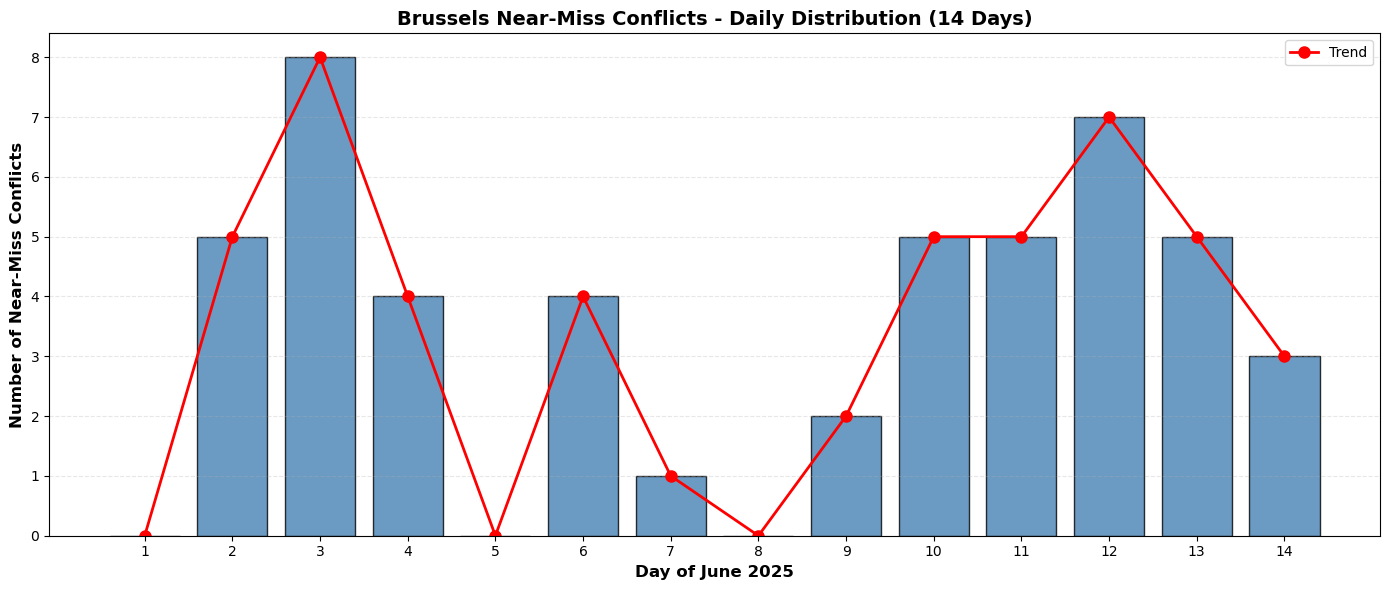

Mean: 3.5 | Std: 2.6 | Max: 8


In [7]:
fig, ax = plt.subplots(figsize=(14, 6))

ax.bar(stats_df['Day'], stats_df['Conflicts'], color='steelblue', alpha=0.8, edgecolor='black')
ax.plot(stats_df['Day'], stats_df['Conflicts'], color='red', marker='o', linewidth=2, markersize=8, label='Trend')

ax.set_xlabel('Day of June 2025', fontsize=12, fontweight='bold')
ax.set_ylabel('Number of Near-Miss Conflicts', fontsize=12, fontweight='bold')
ax.set_title('Brussels Near-Miss Conflicts - Daily Distribution (14 Days)', fontsize=14, fontweight='bold')
ax.set_xticks(range(1, 15))
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.legend()

plt.tight_layout()
plt.show()

print(f"Mean: {stats_df['Conflicts'].mean():.1f} | Std: {stats_df['Conflicts'].std():.1f} | Max: {stats_df['Conflicts'].max()}")

## 4. Load Ghost Zones (Road Map Base)

In [8]:
from shapely.geometry import Polygon
from shapely import wkt
import geopandas as gpd
# Define the specific zone polygon
zone_wkt = ("POLYGON ((-28.977 34.253, -12.788 47.989, 11.576 19.046, 19.752 15.448, "
    "39.702 53.876, 48.205 49.788, 42.809 39.649, 43.136 36.215, 55.073 21.826, "
    "71.915 27.549, 76.167 19.046, 36.104 3.675, 36.104 -2.376, 46.733 -13.168, "
    "52.457 -24.287, 58.097 -31.792, 48.598 -39.498, 31.753 -19.785, 25.122 -23.907, "
    "1.466 -11.721, -28.821 -22.652, -30.792 -17.276, 0.032 -5.986, -1.402 1.003, "
    "-28.977 34.253))")

# Create GeoDataFrame with the zone
zone_geom = wkt.loads(zone_wkt)
gdf_zones = gpd.GeoDataFrame(
    [{'name': 'Analysis Zone', 'geometry': zone_geom}],
    geometry='geometry'
)

print(f"✓ Loaded custom analysis zone")
print(f"✓ Zone area: {zone_geom.area:.2f} m²")
print(f"✓ Zone bounds: {zone_geom.bounds}")

✓ Loaded custom analysis zone
✓ Zone area: 3707.87 m²
✓ Zone bounds: (-30.792, -39.498, 76.167, 53.876)


## 5. Create Risk Heatmap with Influence Circles

In [9]:
def create_risk_heatmap(conflicts_df, gdf_zones, influence_radius=3.0, grid_resolution=0.5):
    """
    Create risk heatmap using influence circles.
    
    Args:
        conflicts_df: DataFrame with conflict locations (pos_x1, pos_y1)
        gdf_zones: GeoDataFrame with zone geometries
        influence_radius: Radius of influence circle in meters
        grid_resolution: Grid cell size in meters
    """
    # Get conflict locations
    if 'pos_x1' in conflicts_df.columns and 'pos_y1' in conflicts_df.columns:
        conflict_points = conflicts_df[['pos_x1', 'pos_y1']].dropna()
    else:
        print("⚠ No position columns found, checking alternatives...")
        print(f"Available columns: {conflicts_df.columns.tolist()}")
        return None
    
    print(f"Processing {len(conflict_points):,} conflict locations...")
    
    # Determine grid bounds from zones
    bounds = gdf_zones.total_bounds  # [minx, miny, maxx, maxy]
    x_min, y_min, x_max, y_max = bounds
    
    # Add padding
    padding = 10
    x_min -= padding
    y_min -= padding
    x_max += padding
    y_max += padding
    
    print(f"Grid bounds: X[{x_min:.1f}, {x_max:.1f}], Y[{y_min:.1f}, {y_max:.1f}]")
    
    # Create grid
    x_range = np.arange(x_min, x_max, grid_resolution)
    y_range = np.arange(y_min, y_max, grid_resolution)
    X, Y = np.meshgrid(x_range, y_range)
    
    # Initialize strength grid
    strength = np.zeros_like(X)
    
    # Add influence from each conflict
    print(f"Computing influence circles (radius={influence_radius}m)...")
    for idx, row in conflict_points.iterrows():
        # Get x, y coordinates from row
        x, y = row['pos_x1'], row['pos_y1']
        
        # Compute distance from this conflict to all grid points
        dist = np.sqrt((X - x)**2 + (Y - y)**2)
        
        # Add influence (1 within radius, 0 outside)
        # Using Gaussian influence for smoother heatmap
        influence = np.exp(-0.5 * (dist / influence_radius)**2)
        strength += influence
    
    # Normalize strength to [0, 1]
    if strength.max() > 0:
        strength_normalized = strength / strength.max()
    else:
        strength_normalized = strength
    
    print(f"✓ Heatmap created: Max strength = {strength.max():.2f}")
    
    return X, Y, strength_normalized, bounds

In [10]:
# Generate heatmap
if len(df_all) > 0:
    print("Creating risk heatmap...\n")
    heatmap_data = create_risk_heatmap(df_all, gdf_zones, influence_radius=3.0, grid_resolution=0.5)
else:
    print("No conflict data available for heatmap.")
    heatmap_data = None

Creating risk heatmap...

Processing 49 conflict locations...
Grid bounds: X[-40.8, 86.2], Y[-49.5, 63.9]
Computing influence circles (radius=3.0m)...
✓ Heatmap created: Max strength = 5.46


## 6. Visualize Risk Heatmap on Road Network

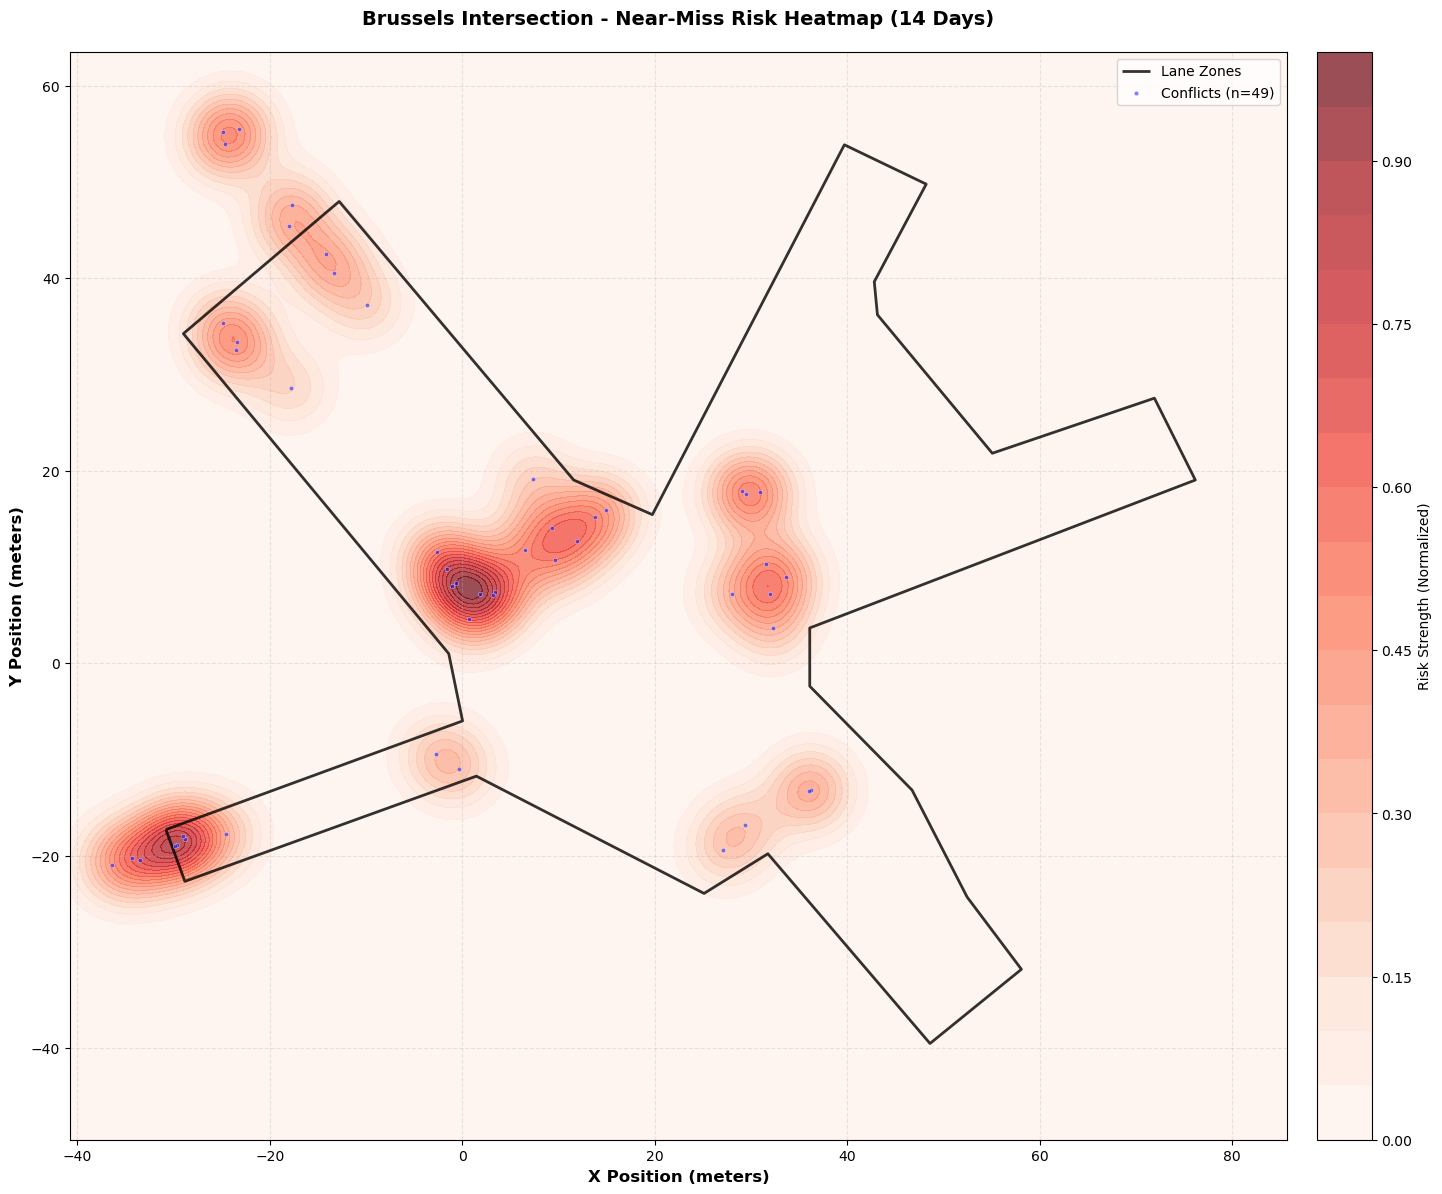


RISK HEATMAP INTERPRETATION
• Darker red = Higher risk (more conflicts)
• Blue points = Individual conflict locations
• Black lines = Lane zone boundaries
• Influence radius: 3.0 meters
• Total conflicts: 49


In [11]:
if heatmap_data is not None:
    X, Y, strength, bounds = heatmap_data
    
    # Create figure
    fig, ax = plt.subplots(figsize=(16, 12))
    
    # Plot heatmap
    heatmap = ax.contourf(X, Y, strength, levels=20, cmap='Reds', alpha=0.7, vmin=0, vmax=1)
    
    # Plot zone boundaries (roads)
    gdf_zones.boundary.plot(ax=ax, color='black', linewidth=2, alpha=0.8, label='Lane Zones')
    
    # Plot conflict points
    if 'pos_x1' in df_all.columns:
        ax.scatter(df_all['pos_x1'], df_all['pos_y1'], 
                   c='blue', s=10, alpha=0.5, edgecolors='white', linewidths=0.5,
                   label=f'Conflicts (n={len(df_all):,})', zorder=5)
    
    # Add colorbar
    cbar = plt.colorbar(heatmap, ax=ax, label='Risk Strength (Normalized)', pad=0.02)
    cbar.ax.tick_params(labelsize=10)
    
    # Styling
    ax.set_xlabel('X Position (meters)', fontsize=12, fontweight='bold')
    ax.set_ylabel('Y Position (meters)', fontsize=12, fontweight='bold')
    ax.set_title('Brussels Intersection - Near-Miss Risk Heatmap (14 Days)', 
                 fontsize=14, fontweight='bold', pad=20)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.legend(loc='upper right', fontsize=10)
    
    plt.tight_layout()
    plt.show()
    
    print("\n" + "="*50)
    print("RISK HEATMAP INTERPRETATION")
    print("="*50)
    print("• Darker red = Higher risk (more conflicts)")
    print("• Blue points = Individual conflict locations")
    print("• Black lines = Lane zone boundaries")
    print(f"• Influence radius: 3.0 meters")
    print(f"• Total conflicts: {len(df_all):,}")
    print("="*50)
else:
    print("Cannot create heatmap - no data available.")

## 7. High-Risk Zone Identification

In [12]:
if heatmap_data is not None and len(df_all) > 0:
    X, Y, strength, bounds = heatmap_data
    
    # Find high-risk areas (top 10%)
    threshold = np.percentile(strength[strength > 0], 90)
    high_risk_mask = strength >= threshold
    
    # Get coordinates of high-risk cells
    high_risk_coords = np.column_stack([X[high_risk_mask], Y[high_risk_mask]])
    
    print("="*50)
    print("HIGH-RISK AREAS (Top 10%)")
    print("="*50)
    print(f"Risk threshold: {threshold:.3f}")
    print(f"High-risk cells: {len(high_risk_coords):,}")
    print(f"\nHigh-risk area coverage: {len(high_risk_coords) * 0.5 * 0.5:.1f} m²")
    
    # Zone-wise conflict counts
    print("\nConflict distribution by metric:")
    if 'label1' in df_all.columns and 'label2' in df_all.columns:
        label_map = {1: 'Ped', 2: 'Bike', 3: 'Moto', 4: 'Car', 5: 'Scoot', 6: 'Van', 7: 'Truck', 8: 'Bus'}
        df_all['pair_type'] = df_all.apply(
            lambda r: f"{label_map.get(r['label1'], r['label1'])}-{label_map.get(r['label2'], r['label2'])}", 
            axis=1
        )
        print("\nTop 5 conflict pair types:")
        print(df_all['pair_type'].value_counts().head())
    
    print("="*50)

HIGH-RISK AREAS (Top 10%)
Risk threshold: 0.109
High-risk cells: 5,766

High-risk area coverage: 1441.5 m²

Conflict distribution by metric:

Top 5 conflict pair types:
pair_type
nan-nan     33
Bike-Ped     9
Ped-Bike     3
Bus-Ped      2
Van-Ped      1
Name: count, dtype: int64


## 8. Save Results

In [13]:
# Save daily statistics
output_path = Path("/home/ubuntu/prem/results/brussels/analysis")
output_path.mkdir(parents=True, exist_ok=True)

stats_path = output_path / "daily_nearmiss_stats.csv"
stats_df.to_csv(stats_path, index=False)
print(f"✓ Saved daily statistics to {stats_path}")

# Save heatmap figure (only if it was created)
if heatmap_data is not None and 'fig' in locals():
    fig.savefig(output_path / "risk_heatmap.png", dpi=300, bbox_inches='tight')
    print(f"✓ Saved heatmap to {output_path / 'risk_heatmap.png'}")
else:
    print("⚠ Heatmap figure not saved (no data or figure not created)")

✓ Saved daily statistics to /home/ubuntu/prem/results/brussels/analysis/daily_nearmiss_stats.csv


✓ Saved heatmap to /home/ubuntu/prem/results/brussels/analysis/risk_heatmap.png
